In [1]:

import os, glob, random, math, json, time, shutil
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from torchvision.models import resnet18, resnet34, resnet50
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

BACKBONE_FNS = {
    "resnet18": resnet18,
    "resnet34": resnet34,
    "resnet50": resnet50,
}

Device: cuda


In [2]:
# ---- Paths: adjust ROOT if your Kaggle dataset mount path differs ----
ROOT = Path("/kaggle/input/datasets/afqwe0/clotheslabelled")   # change to your actual dataset slug/path
PERSON_FOLDERS = ["Himesh", "Pratik", "Sworup", "Mahesh"]
LABELS_DIR = ROOT / "Labels"

# Working directory for crops (Kaggle input is read-only, so crops go to /kaggle/working)
WORK_DIR = Path("/kaggle/working")
CROPS_DIR = WORK_DIR / "crops"
CROPS_DIR.mkdir(parents=True, exist_ok=True)

BACKBONE_NAME = "resnet18" 
IMG_SIZE = 224
BATCH_SIZE = 64
EMBED_DIM = 64
NUM_CLASSES = 25
EPOCHS = 50 # Less epochs for resnet18 might cause overfitting, so I tried 
# increasing the no of epchos and depend on the checkpoint save logic in 
# case sth happens.
LR = 3e-4
WEIGHT_DECAY = 1e-4

# CutMix / MixUp
MIX_PROB = 0.5          # probability of applying a mix augmentation per batch
MIXUP_ALPHA = 0.2
CUTMIX_ALPHA = 1.0

# Triplet
TRIPLET_MARGIN = 0.3

# NT-Xent
NTXENT_TEMPERATURE = 0.5

# Loss weighting between metric loss and classification loss
LAMBDA_CLS = 0.5

# PK batch sampling (P classes x K samples/class per batch) for the metric-learning
# branches: with 811 vs 61 samples across classes, plain shuffle=True batches often
# contain 0-1 samples of minority classes, starving triplet mining and creating
# same-class false negatives in NT-Xent
PK_P = 16
PK_K = 4

# Linear LR warmup (in epochs) before cosine decay, for stabler from-scratch training
WARMUP_EPOCHS = 3


In [3]:

# class_id -> class_name, must match the order/indices used when labels were generated
CLASS_NAMES = {
    0: "t_shirt",
    1: "trousers",
    2: "blazer",
    3: "hoodie",
    4: "sneakers",
    5: "dolphin_shorts",
    6: "denim_shorts",
    7: "fit_and_flare_dress",
    8: "jacket",
    9: "skirt",
    10: "men_suits_western_coatpant",
    11: "loafers",
    12: "formal_pants_shirt_set",
    13: "dhaka_topi",
    14: "sari",
    15: "baggy_pants",
    16: "jeans_pants",
    17: "one_piece",
    18: "sweatshirt",
    19: "caps",
    20: "cardigan",
    21: "cowl_neck_top",
    22: "turtleneck",
    23: "polo",
    24: "sweater",
}
assert len(CLASS_NAMES) == NUM_CLASSES
NAME_TO_ID = {v: k for k, v in CLASS_NAMES.items()}
print(CLASS_NAMES)

{0: 't_shirt', 1: 'trousers', 2: 'blazer', 3: 'hoodie', 4: 'sneakers', 5: 'dolphin_shorts', 6: 'denim_shorts', 7: 'fit_and_flare_dress', 8: 'jacket', 9: 'skirt', 10: 'men_suits_western_coatpant', 11: 'loafers', 12: 'formal_pants_shirt_set', 13: 'dhaka_topi', 14: 'sari', 15: 'baggy_pants', 16: 'jeans_pants', 17: 'one_piece', 18: 'sweatshirt', 19: 'caps', 20: 'cardigan', 21: 'cowl_neck_top', 22: 'turtleneck', 23: 'polo', 24: 'sweater'}


In [4]:

def find_all_images():
    """Recursively find all images under the 4 person folders."""
    exts = ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG")
    paths = []
    for person in PERSON_FOLDERS:
        person_dir = ROOT / person
        if not person_dir.exists():
            print(f"WARNING: {person_dir} not found, skipping")
            continue
        for ext in exts:
            paths.extend(person_dir.rglob(ext))
    return paths

def load_yolo_labels(label_path, img_w, img_h):
    """Parse a YOLO label file into a list of (class_id, x1, y1, x2, y2) in pixel coords."""
    boxes = []
    if not label_path.exists():
        return boxes
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id, xc, yc, w, h = int(parts[0]), *map(float, parts[1:])
            x1 = (xc - w / 2) * img_w
            y1 = (yc - h / 2) * img_h
            x2 = (xc + w / 2) * img_w
            y2 = (yc + h / 2) * img_h
            boxes.append((cls_id, max(0, x1), max(0, y1), min(img_w, x2), min(img_h, y2)))
    return boxes

def crop_all(min_box_size=20):
    all_images = find_all_images()
    print(f"Found {len(all_images)} source images")

    manifest = []  # rows: crop_path, class_id, class_name, source_image, person
    skipped_no_label = 0
    skipped_tiny = 0

    for img_path in all_images:
        label_path = LABELS_DIR / f"{img_path.stem}.txt"
        try:
            with Image.open(img_path) as im:
                im = im.convert("RGB")
                w, h = im.size
                boxes = load_yolo_labels(label_path, w, h)
                if not boxes:
                    skipped_no_label += 1
                    continue
                person = img_path.parts[-2] if img_path.parent.name in PERSON_FOLDERS else img_path.parent.name
                for i, (cls_id, x1, y1, x2, y2) in enumerate(boxes):
                    if (x2 - x1) < min_box_size or (y2 - y1) < min_box_size:
                        skipped_tiny += 1
                        continue
                    crop = im.crop((x1, y1, x2, y2))
                    cls_name = CLASS_NAMES.get(cls_id, f"unknown_{cls_id}")
                    out_dir = CROPS_DIR / cls_name
                    out_dir.mkdir(parents=True, exist_ok=True)
                    out_path = out_dir / f"{img_path.stem}_{i}.jpg"
                    crop.save(out_path, quality=95)
                    manifest.append({
                        "crop_path": str(out_path),
                        "class_id": cls_id,
                        "class_name": cls_name,
                        "source_image": str(img_path),
                        "person": person,
                    })
        except Exception as e:
            print(f"Error processing {img_path}: {e}")

    print(f"Skipped (no label file): {skipped_no_label}")
    print(f"Skipped (box too small): {skipped_tiny}")
    print(f"Total crops generated: {len(manifest)}")
    return pd.DataFrame(manifest)

manifest_path = WORK_DIR / "manifest.csv"
if manifest_path.exists():
    df = pd.read_csv(manifest_path)
    print(f"Loaded existing manifest with {len(df)} crops")
else:
    df = crop_all()
    df.to_csv(manifest_path, index=False)

df["class_name"].value_counts()


Found 2860 source images
Skipped (no label file): 68
Skipped (box too small): 0
Total crops generated: 4773


class_name
men_suits_western_coatpant    811
loafers                       589
formal_pants_shirt_set        339
skirt                         228
fit_and_flare_dress           228
hoodie                        222
dhaka_topi                    186
denim_shorts                  169
cowl_neck_top                 167
sneakers                      145
sari                          143
cardigan                      141
jeans_pants                   135
sweatshirt                    134
polo                          132
dolphin_shorts                124
t_shirt                       114
one_piece                     112
caps                          110
baggy_pants                   105
trousers                      102
sweater                        98
blazer                         98
turtleneck                     80
jacket                         61
Name: count, dtype: int64

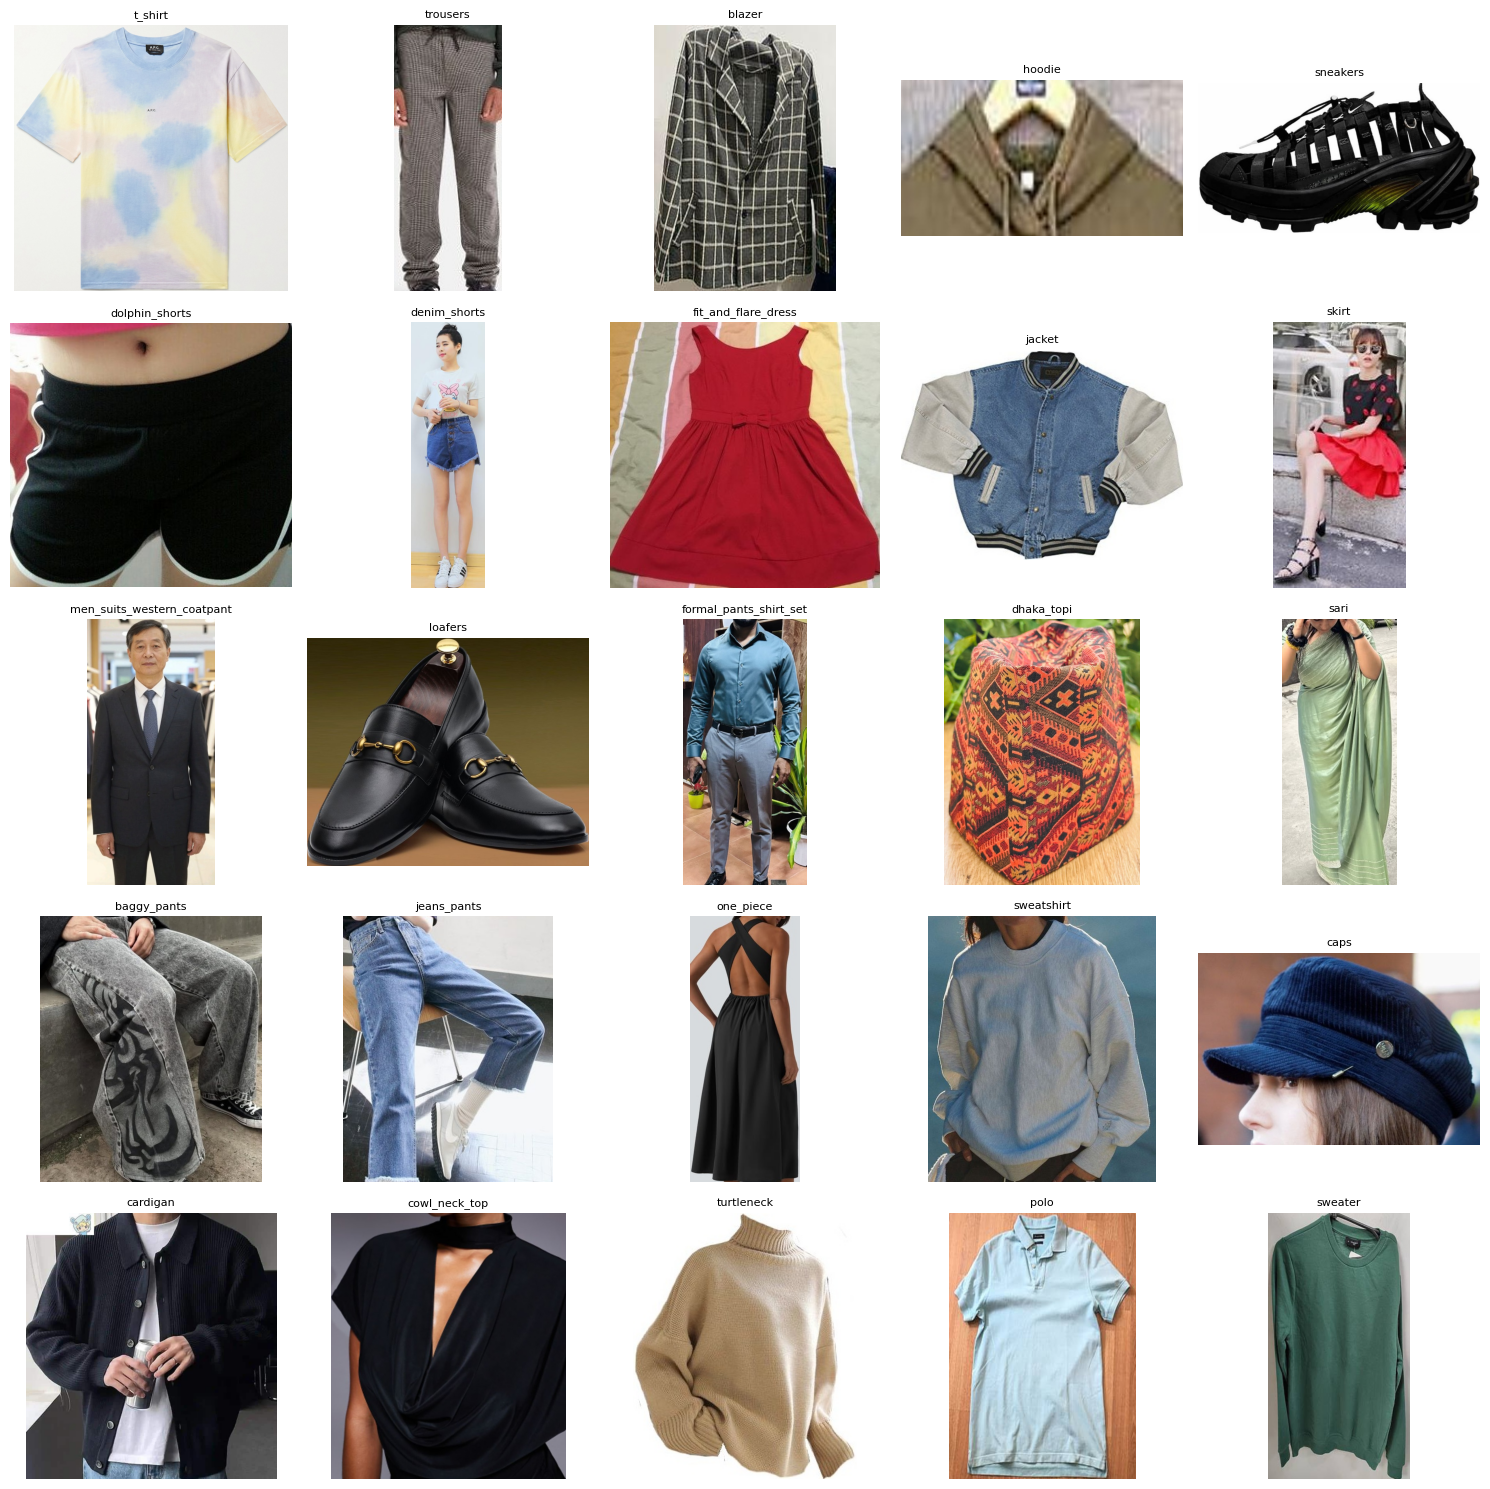

In [5]:

# Quick sanity check: visualize a few crops per class
fig, axes = plt.subplots(5, 5, figsize=(15, 15))
for ax, (cls_id, cls_name) in zip(axes.flat, CLASS_NAMES.items()):
    sub = df[df["class_id"] == cls_id]
    ax.axis("off")
    ax.set_title(cls_name, fontsize=8)
    if len(sub) > 0:
        sample_path = sub.sample(1, random_state=SEED).iloc[0]["crop_path"]
        try:
            img = Image.open(sample_path)
            ax.imshow(img)
        except Exception:
            pass
plt.tight_layout()
plt.show()


In [6]:

from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["class_id"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["class_id"], random_state=SEED
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
train_df["class_name"].value_counts()


Train: 3341 | Val: 716 | Test: 716


class_name
men_suits_western_coatpant    568
loafers                       412
formal_pants_shirt_set        237
skirt                         160
fit_and_flare_dress           160
hoodie                        155
dhaka_topi                    130
denim_shorts                  118
cowl_neck_top                 117
sneakers                      101
sari                          100
cardigan                       99
sweatshirt                     94
jeans_pants                    94
polo                           92
dolphin_shorts                 87
t_shirt                        80
one_piece                      78
caps                           77
baggy_pants                    74
trousers                       71
sweater                        69
blazer                         69
turtleneck                     56
jacket                         43
Name: count, dtype: int64

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.1),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Stronger augmentation used specifically for the two NT-Xent views,
# since contrastive learning benefits from more aggressive augmentation
contrastive_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class ClassificationDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["crop_path"]).convert("RGB")
        img = self.transform(img)
        label = int(row["class_id"])
        return img, label


class ContrastiveDataset(Dataset):
    """Returns two augmented views of the same image, plus its class label
    (label is used only for monitoring/evaluation, not for the NT-Xent loss itself)."""
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["crop_path"]).convert("RGB")
        view1 = self.transform(img)
        view2 = self.transform(img)
        label = int(row["class_id"])
        return view1, view2, label


class PKSampler(torch.utils.data.Sampler):
    """Yields batches of P classes x K samples each so every triplet/NT-Xent batch
    has real intra-class pairs to mine. Plain shuffle=True is biased toward the
    dominant classes (811 for men_suits_western_coatpant vs 61 for jacket), so
    minority classes routinely got 0-1 samples per batch -- starving triplet's
    hardest-positive mining and creating same-class false negatives in NT-Xent."""
    def __init__(self, labels, p=PK_P, k=PK_K, seed=SEED):
        self.labels = np.asarray(labels)
        self.p = p
        self.k = k
        self.classes = np.unique(self.labels)
        self.class_to_indices = {c: np.where(self.labels == c)[0] for c in self.classes}
        self.batch_size = p * k
        self.num_batches = len(self.labels) // self.batch_size
        self.rng = np.random.RandomState(seed)

    def __iter__(self):
        for _ in range(self.num_batches):
            chosen_classes = self.rng.choice(
                self.classes, size=self.p, replace=len(self.classes) < self.p
            )
            batch = []
            for c in chosen_classes:
                idxs = self.class_to_indices[c]
                batch.extend(self.rng.choice(idxs, size=self.k, replace=len(idxs) < self.k).tolist())
            self.rng.shuffle(batch)
            yield batch

    def __len__(self):
        return self.num_batches


train_cls_ds = ClassificationDataset(train_df, train_tf)
val_cls_ds   = ClassificationDataset(val_df, eval_tf)
test_cls_ds  = ClassificationDataset(test_df, eval_tf)

train_con_ds = ContrastiveDataset(train_df, contrastive_tf)
val_con_ds   = ContrastiveDataset(val_df, eval_tf)  # eval views: deterministic, single-purpose
test_con_ds  = ContrastiveDataset(test_df, eval_tf)

train_cls_sampler = PKSampler(train_df["class_id"].values)
train_con_sampler = PKSampler(train_df["class_id"].values)

train_cls_loader = DataLoader(train_cls_ds, batch_sampler=train_cls_sampler, num_workers=0)
val_cls_loader   = DataLoader(val_cls_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_cls_loader  = DataLoader(test_cls_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

train_con_loader = DataLoader(train_con_ds, batch_sampler=train_con_sampler, num_workers=0)
val_con_loader   = DataLoader(val_con_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_con_loader  = DataLoader(test_con_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Loaders ready. PK sampler: {PK_P} classes x {PK_K} samples/class = "
      f"batch size {PK_P * PK_K}, {len(train_cls_sampler)} batches/epoch.")


Loaders ready. PK sampler: 16 classes x 4 samples/class = batch size 64, 52 batches/epoch.


In [8]:

def rand_bbox(size, lam):
    W, H = size[3], size[2]
    cut_rat = math.sqrt(1. - lam)
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y2 = np.clip(cy + cut_h // 2, 0, H)
    return x1, y1, x2, y2


def apply_mixup_cutmix(images, labels, num_classes, mixup_alpha=MIXUP_ALPHA, cutmix_alpha=CUTMIX_ALPHA, prob=MIX_PROB):
    """Returns mixed images, and (label_a, label_b, lam) for a soft-label loss."""
    labels_onehot = F.one_hot(labels, num_classes).float()

    if np.random.rand() > prob:
        return images, labels_onehot, labels_onehot, 1.0  # no mixing

    use_cutmix = np.random.rand() < 0.5
    batch_size = images.size(0)
    perm = torch.randperm(batch_size, device=images.device)

    if use_cutmix:
        lam = np.random.beta(cutmix_alpha, cutmix_alpha)
        x1, y1, x2, y2 = rand_bbox(images.size(), lam)
        images[:, :, y1:y2, x1:x2] = images[perm, :, y1:y2, x1:x2]
        lam = 1 - ((x2 - x1) * (y2 - y1) / (images.size(-1) * images.size(-2)))
    else:
        lam = np.random.beta(mixup_alpha, mixup_alpha)
        images = lam * images + (1 - lam) * images[perm]

    labels_a = labels_onehot
    labels_b = labels_onehot[perm]
    return images, labels_a, labels_b, lam


def soft_ce_loss(logits, labels_a, labels_b, lam):
    log_probs = F.log_softmax(logits, dim=1)
    loss_a = -(labels_a * log_probs).sum(dim=1)
    loss_b = -(labels_b * log_probs).sum(dim=1)
    return (lam * loss_a + (1 - lam) * loss_b).mean()


In [9]:

def replace_relu_with_gelu(module):
    """Recursively replace every nn.ReLU in a module with nn.GELU."""
    for name, child in module.named_children():
        if isinstance(child, nn.ReLU):
            setattr(module, name, nn.GELU())
        else:
            replace_relu_with_gelu(child)
    return module


class EmbeddingResNet(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES, backbone_name=BACKBONE_NAME):
        super().__init__()
        backbone = BACKBONE_FNS[backbone_name](weights=None)
        backbone = replace_relu_with_gelu(backbone)
        feat_dim = backbone.fc.in_features  # 512 for resnet 18/34, 2048 for resnet50
        backbone.fc = nn.Identity()
        self.backbone = backbone

        self.projection_head = nn.Sequential(
            nn.Linear(feat_dim, feat_dim),
            nn.GELU(),
            nn.Linear(feat_dim, embed_dim),
        )

        self.classification_head = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x, return_logits=True):
        feats = self.backbone(x)
        embedding = F.normalize(self.projection_head(feats), dim=1)
        if return_logits:
            logits = self.classification_head(feats)
            return embedding, logits
        return embedding


def build_model():
    model = EmbeddingResNet().to(DEVICE)
    return model

# quick shape check
_m = build_model()
_x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
_emb, _logits = _m(_x)
print("embedding shape:", _emb.shape, "| logits shape:", _logits.shape)
del _m, _x, _emb, _logits
torch.cuda.empty_cache()


embedding shape: torch.Size([2, 64]) | logits shape: torch.Size([2, 25])


In [10]:

def pairwise_distances(embeddings, squared=False):
    dot = torch.matmul(embeddings, embeddings.t())
    sq_norm = torch.diagonal(dot)
    distances = sq_norm.unsqueeze(0) - 2 * dot + sq_norm.unsqueeze(1)
    distances = torch.clamp(distances, min=0.0)
    if not squared:
        mask = (distances == 0.0).float()
        distances = distances + mask * 1e-16
        distances = torch.sqrt(distances)
        distances = distances * (1.0 - mask)
    return distances


def batch_hard_triplet_loss(embeddings, labels, margin=TRIPLET_MARGIN):
    pdist = pairwise_distances(embeddings)
    labels = labels.unsqueeze(1)
    same_mask = (labels == labels.t())
    diff_mask = ~same_mask
    eye = torch.eye(labels.size(0), device=labels.device, dtype=torch.bool)
    same_mask = same_mask & ~eye

    # hardest positive: max distance among same-class pairs
    pos_dist = pdist.clone()
    pos_dist[~same_mask] = -1.0
    hardest_pos = pos_dist.max(dim=1)[0]

    # hardest negative: min distance among different-class pairs
    neg_dist = pdist.clone()
    neg_dist[~diff_mask] = float("inf")
    hardest_neg = neg_dist.min(dim=1)[0]

    losses = F.relu(hardest_pos - hardest_neg + margin)
    # ignore anchors with no valid positive in the batch
    valid = same_mask.any(dim=1)
    if valid.sum() == 0:
        return losses.sum() * 0.0
    return losses[valid].mean()


def nt_xent_loss(z1, z2, temperature=NTXENT_TEMPERATURE):
    """z1, z2: (B, D) L2-normalized embeddings of two views of the same B images."""
    batch_size = z1.size(0)
    z = torch.cat([z1, z2], dim=0)  # (2B, D)
    sim = torch.matmul(z, z.t()) / temperature  # (2B, 2B)

    # mask out self-similarity
    mask = torch.eye(2 * batch_size, device=z.device, dtype=torch.bool)
    sim.masked_fill_(mask, float("-inf"))

    # positive pair indices: i <-> i+B
    targets = torch.cat([
        torch.arange(batch_size, 2 * batch_size),
        torch.arange(0, batch_size),
    ]).to(z.device)

    loss = F.cross_entropy(sim, targets)
    return loss


In [11]:
def train_one_epoch_triplet(model, loader, optimizer, num_classes):
    model.train()
    total_triplet, total_cls, total_loss, n_batches = 0.0, 0.0, 0.0, 0

    pbar = tqdm(loader, desc="Train (triplet)", leave=False)
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        # --- metric branch: clean images ---
        embeddings, _ = model(images)
        t_loss = batch_hard_triplet_loss(embeddings, labels)

        # --- classification branch: mixed images ---
        mixed_images = images.clone()
        mixed_images, labels_a, labels_b, lam = apply_mixup_cutmix(mixed_images, labels, num_classes)
        _, mixed_logits = model(mixed_images)
        c_loss = soft_ce_loss(mixed_logits, labels_a, labels_b, lam)

        loss = t_loss + LAMBDA_CLS * c_loss
        loss.backward()
        optimizer.step()

        total_triplet += t_loss.item()
        total_cls += c_loss.item()
        total_loss += loss.item()
        n_batches += 1

        pbar.set_postfix(triplet=f"{t_loss.item():.4f}", cls=f"{c_loss.item():.4f}")

    return total_loss / n_batches, total_triplet / n_batches, total_cls / n_batches

@torch.no_grad()
def validate_triplet(model, loader):
    model.eval()
    total_loss, n_batches = 0.0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        embeddings, _ = model(images)
        loss = batch_hard_triplet_loss(embeddings, labels)
        total_loss += loss.item()
        n_batches += 1
    return total_loss / max(n_batches, 1)

In [12]:
model_triplet = build_model()
optimizer_triplet = torch.optim.AdamW(model_triplet.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
warmup_triplet = torch.optim.lr_scheduler.LinearLR(optimizer_triplet, start_factor=0.1, total_iters=WARMUP_EPOCHS)
cosine_triplet = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_triplet, T_max=EPOCHS - WARMUP_EPOCHS)
scheduler_triplet = torch.optim.lr_scheduler.SequentialLR(
    optimizer_triplet, schedulers=[warmup_triplet, cosine_triplet], milestones=[WARMUP_EPOCHS]
)

history_triplet = {"train_loss": [], "train_triplet": [], "train_cls": [], "val_loss": []}
best_val_triplet = float("inf")
TRIPLET_CKPT = WORK_DIR / "model_triplet_best.pt"

epoch_pbar = tqdm(range(EPOCHS), desc="Epochs (triplet)")
for epoch in epoch_pbar:
    t0 = time.time()
    tr_loss, tr_trip, tr_cls = train_one_epoch_triplet(model_triplet, train_cls_loader, optimizer_triplet, NUM_CLASSES)
    val_loss = validate_triplet(model_triplet, val_cls_loader)
    scheduler_triplet.step()

    history_triplet["train_loss"].append(tr_loss)
    history_triplet["train_triplet"].append(tr_trip)
    history_triplet["train_cls"].append(tr_cls)
    history_triplet["val_loss"].append(val_loss)

    if val_loss < best_val_triplet:
        best_val_triplet = val_loss
        torch.save(model_triplet.state_dict(), TRIPLET_CKPT)

    epoch_pbar.set_postfix(
        train_loss=f"{tr_loss:.4f}", val_loss=f"{val_loss:.4f}", best=f"{best_val_triplet:.4f}"
    )

print(f"Best val triplet loss: {best_val_triplet:.4f}, checkpoint saved to {TRIPLET_CKPT}")  

Epochs (triplet):   0%|          | 0/50 [00:00<?, ?it/s]

Train (triplet):   0%|          | 0/52 [00:00<?, ?it/s]

Train (triplet):   0%|          | 0/52 [00:00<?, ?it/s]

Train (triplet):   0%|          | 0/52 [00:00<?, ?it/s]

Train (triplet):   0%|          | 0/52 [00:00<?, ?it/s]

...

Train (triplet):   0%|          | 0/52 [00:00<?, ?it/s]

Train (triplet):   0%|          | 0/52 [00:00<?, ?it/s]

Train (triplet):   0%|          | 0/52 [00:00<?, ?it/s]

Train (triplet):   0%|          | 0/52 [00:00<?, ?it/s]

Best val triplet loss: 0.3012, checkpoint saved to /kaggle/working/model_triplet_best.pt


In [13]:
def train_one_epoch_ntxent(model, loader, optimizer, num_classes):
    model.train()
    total_ntxent, total_cls, total_loss, n_batches = 0.0, 0.0, 0.0, 0

    pbar = tqdm(loader, desc="Train (ntxent)", leave=False)
    for view1, view2, labels in pbar:
        view1, view2, labels = view1.to(DEVICE), view2.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        z1, _ = model(view1)
        z2, _ = model(view2)
        c_loss_ntxent = nt_xent_loss(z1, z2)

        mixed_images = view1.clone()
        mixed_images, labels_a, labels_b, lam = apply_mixup_cutmix(mixed_images, labels, num_classes)
        _, mixed_logits = model(mixed_images)
        c_loss_cls = soft_ce_loss(mixed_logits, labels_a, labels_b, lam)

        loss = c_loss_ntxent + LAMBDA_CLS * c_loss_cls
        loss.backward()
        optimizer.step()

        total_ntxent += c_loss_ntxent.item()
        total_cls += c_loss_cls.item()
        total_loss += loss.item()
        n_batches += 1

        pbar.set_postfix(ntxent=f"{c_loss_ntxent.item():.4f}", cls=f"{c_loss_cls.item():.4f}")

    return total_loss / n_batches, total_ntxent / n_batches, total_cls / n_batches

@torch.no_grad()
def validate_ntxent(model, loader):
    model.eval()
    total_loss, n_batches = 0.0, 0
    for view1, view2, labels in loader:
        view1, view2 = view1.to(DEVICE), view2.to(DEVICE)
        z1, _ = model(view1)
        z2, _ = model(view2)
        loss = nt_xent_loss(z1, z2)
        total_loss += loss.item()
        n_batches += 1
    return total_loss / max(n_batches, 1)

In [14]:
model_ntxent = build_model()
optimizer_ntxent = torch.optim.AdamW(model_ntxent.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
warmup_ntxent = torch.optim.lr_scheduler.LinearLR(optimizer_ntxent, start_factor=0.1, total_iters=WARMUP_EPOCHS)
cosine_ntxent = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_ntxent, T_max=EPOCHS - WARMUP_EPOCHS)
scheduler_ntxent = torch.optim.lr_scheduler.SequentialLR(
    optimizer_ntxent, schedulers=[warmup_ntxent, cosine_ntxent], milestones=[WARMUP_EPOCHS]
)

history_ntxent = {"train_loss": [], "train_ntxent": [], "train_cls": [], "val_loss": []}
best_val_ntxent = float("inf")
NTXENT_CKPT = WORK_DIR / "model_ntxent_best.pt"

epoch_pbar = tqdm(range(EPOCHS), desc="Epochs (ntxent)")
for epoch in epoch_pbar:
    t0 = time.time()
    tr_loss, tr_nt, tr_cls = train_one_epoch_ntxent(model_ntxent, train_con_loader, optimizer_ntxent, NUM_CLASSES)
    val_loss = validate_ntxent(model_ntxent, val_con_loader)
    scheduler_ntxent.step()

    history_ntxent["train_loss"].append(tr_loss)
    history_ntxent["train_ntxent"].append(tr_nt)
    history_ntxent["train_cls"].append(tr_cls)
    history_ntxent["val_loss"].append(val_loss)

    if val_loss < best_val_ntxent:
        best_val_ntxent = val_loss
        torch.save(model_ntxent.state_dict(), NTXENT_CKPT)

    epoch_pbar.set_postfix(
        train_loss=f"{tr_loss:.4f}", val_loss=f"{val_loss:.4f}", best=f"{best_val_ntxent:.4f}"
    )

print(f"Best val NT-Xent loss: {best_val_ntxent:.4f}, checkpoint saved to {NTXENT_CKPT}")

Epochs (ntxent):   0%|          | 0/50 [00:00<?, ?it/s]

Train (ntxent):   0%|          | 0/52 [00:00<?, ?it/s]

Train (ntxent):   0%|          | 0/52 [00:00<?, ?it/s]

Train (ntxent):   0%|          | 0/52 [00:00<?, ?it/s]

Train (ntxent):   0%|          | 0/52 [00:00<?, ?it/s]

...

Train (ntxent):   0%|          | 0/52 [00:00<?, ?it/s]

Train (ntxent):   0%|          | 0/52 [00:00<?, ?it/s]

Train (ntxent):   0%|          | 0/52 [00:00<?, ?it/s]

Train (ntxent):   0%|          | 0/52 [00:00<?, ?it/s]

Best val NT-Xent loss: 2.9205, checkpoint saved to /kaggle/working/model_ntxent_best.pt


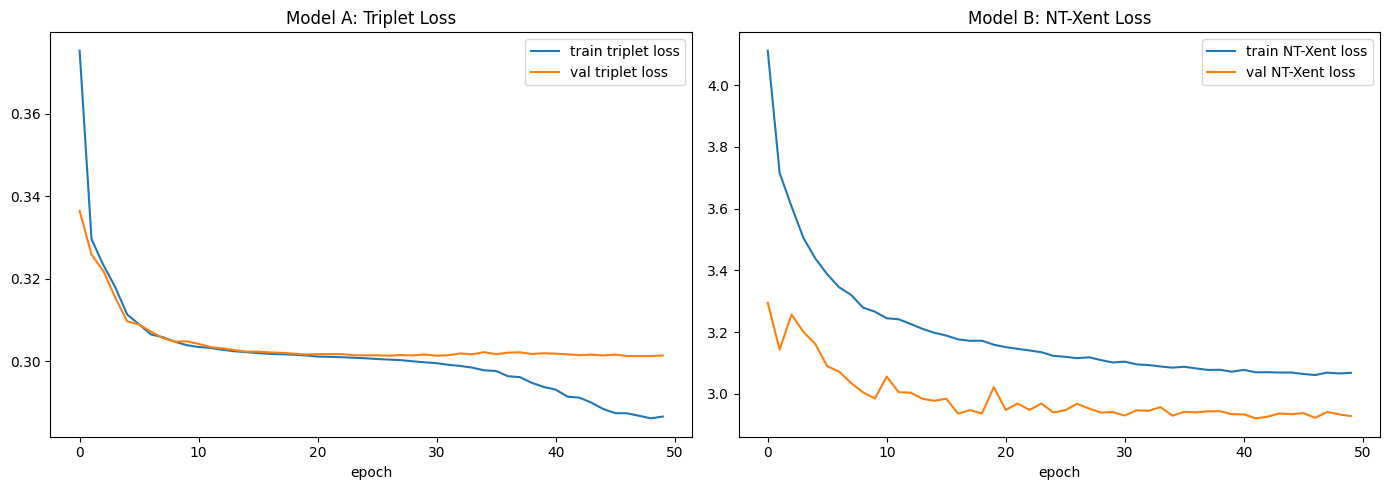

In [15]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_triplet["train_triplet"], label="train triplet loss")
axes[0].plot(history_triplet["val_loss"], label="val triplet loss")
axes[0].set_title("Model A: Triplet Loss")
axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(history_ntxent["train_ntxent"], label="train NT-Xent loss")
axes[1].plot(history_ntxent["val_loss"], label="val NT-Xent loss")
axes[1].set_title("Model B: NT-Xent Loss")
axes[1].set_xlabel("epoch"); axes[1].legend()

plt.tight_layout()
plt.show()


In [16]:

@torch.no_grad()
def extract_embeddings(model, loader):
    model.eval()
    all_embeds, all_labels, all_logits = [], [], []
    for images, labels in loader:
        images = images.to(DEVICE)
        embeds, logits = model(images)
        all_embeds.append(embeds.cpu())
        all_labels.append(labels)
        all_logits.append(logits.cpu())
    return torch.cat(all_embeds), torch.cat(all_labels), torch.cat(all_logits)


def precision_at_k(embeddings, labels, k_values=(1, 5, 10)):
    sim = embeddings @ embeddings.t()
    n = sim.size(0)
    sim.fill_diagonal_(float("-inf"))  # exclude self
    results = {}
    for k in k_values:
        topk = sim.topk(k, dim=1).indices  # (n, k)
        topk_labels = labels[topk]  # (n, k)
        correct = (topk_labels == labels.unsqueeze(1)).float()
        results[f"P@{k}"] = correct.mean().item()
    return results


def mean_average_precision(embeddings, labels):
    sim = embeddings @ embeddings.t()
    n = sim.size(0)
    sim.fill_diagonal_(float("-inf"))
    ranking = sim.argsort(dim=1, descending=True)  # (n, n-ish)
    aps = []
    for i in range(n):
        ranked_labels = labels[ranking[i]]
        relevant = (ranked_labels == labels[i]).float()
        if relevant.sum() == 0:
            continue
        cum_relevant = torch.cumsum(relevant, dim=0)
        precision_at_each = cum_relevant / torch.arange(1, len(relevant) + 1, dtype=torch.float32)
        ap = (precision_at_each * relevant).sum() / relevant.sum()
        aps.append(ap.item())
    return float(np.mean(aps))


# load best checkpoints
model_triplet.load_state_dict(torch.load(TRIPLET_CKPT, map_location=DEVICE))
model_ntxent.load_state_dict(torch.load(NTXENT_CKPT, map_location=DEVICE))

emb_trip, labels_trip, logits_trip = extract_embeddings(model_triplet, test_cls_loader)
emb_nt, labels_nt, logits_nt = extract_embeddings(model_ntxent, test_cls_loader)

cls_acc_trip = (logits_trip.argmax(dim=1) == labels_trip).float().mean().item()
cls_acc_nt = (logits_nt.argmax(dim=1) == labels_nt).float().mean().item()

p_at_k_trip = precision_at_k(emb_trip, labels_trip)
p_at_k_nt = precision_at_k(emb_nt, labels_nt)

map_trip = mean_average_precision(emb_trip, labels_trip)
map_nt = mean_average_precision(emb_nt, labels_nt)

results = pd.DataFrame({
    "Triplet": {**p_at_k_trip, "mAP": map_trip, "cls_acc": cls_acc_trip},
    "NT-Xent": {**p_at_k_nt, "mAP": map_nt, "cls_acc": cls_acc_nt},
}).T

print(results)


              P@1       P@5      P@10       mAP   cls_acc
Triplet  0.837989  0.775978  0.755726  0.676536  0.836592
NT-Xent  0.727654  0.635754  0.579050  0.464250  0.794693


In [17]:

# Decide the winner automatically based on mAP (primary retrieval quality metric)
winner = "Triplet" if map_trip >= map_nt else "NT-Xent"
print(f"\nBetter embedding model by mAP: {winner}")
print(f"Triplet  mAP={map_trip:.4f}, P@1={p_at_k_trip['P@1']:.4f}, cls_acc={cls_acc_trip:.4f}")
print(f"NT-Xent  mAP={map_nt:.4f}, P@1={p_at_k_nt['P@1']:.4f}, cls_acc={cls_acc_nt:.4f}")

winner_model = model_triplet if winner == "Triplet" else model_ntxent
winner_ckpt = TRIPLET_CKPT if winner == "Triplet" else NTXENT_CKPT
FINAL_CKPT = WORK_DIR / "best_embedding_model.pt"
shutil.copy(winner_ckpt, FINAL_CKPT)
print(f"Saved winning model to {FINAL_CKPT}")



Better embedding model by mAP: Triplet
Triplet  mAP=0.6765, P@1=0.8380, cls_acc=0.8366
NT-Xent  mAP=0.4642, P@1=0.7277, cls_acc=0.7947
Saved winning model to /kaggle/working/best_embedding_model.pt


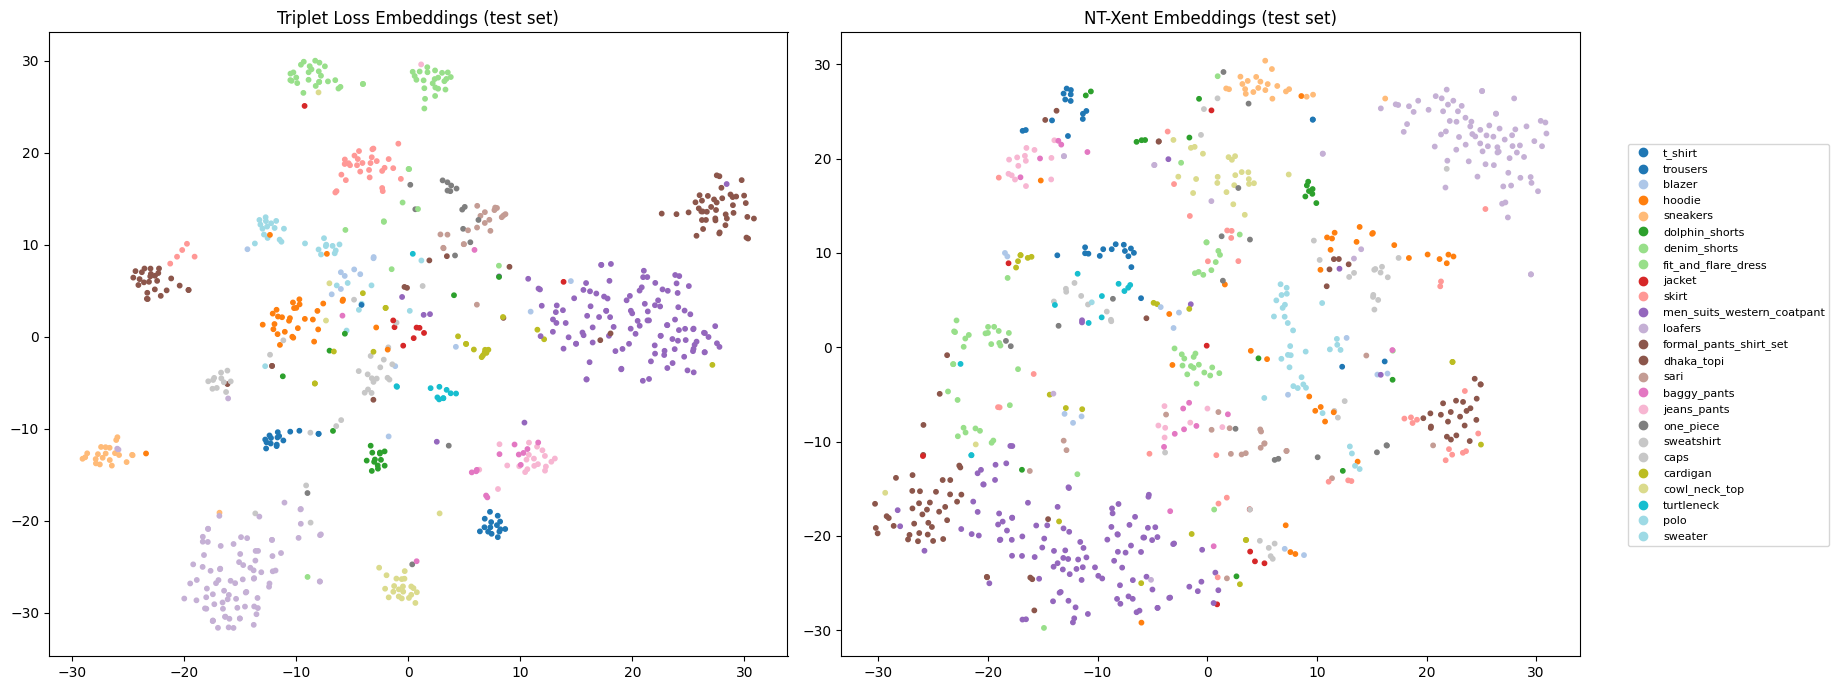

In [18]:

from sklearn.manifold import TSNE

def plot_tsne(embeddings, labels, title, ax):
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, init="pca")
    proj = tsne.fit_transform(embeddings.numpy())
    scatter = ax.scatter(proj[:, 0], proj[:, 1], c=labels.numpy(), cmap="tab20", s=10)
    ax.set_title(title)
    return scatter

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_tsne(emb_trip, labels_trip, "Triplet Loss Embeddings (test set)", axes[0])
sc = plot_tsne(emb_nt, labels_nt, "NT-Xent Embeddings (test set)", axes[1])

handles, _ = sc.legend_elements(num=NUM_CLASSES)
fig.legend(handles, [CLASS_NAMES[i] for i in range(NUM_CLASSES)],
           loc="center right", bbox_to_anchor=(1.15, 0.5), fontsize=8)
plt.tight_layout()
plt.show()


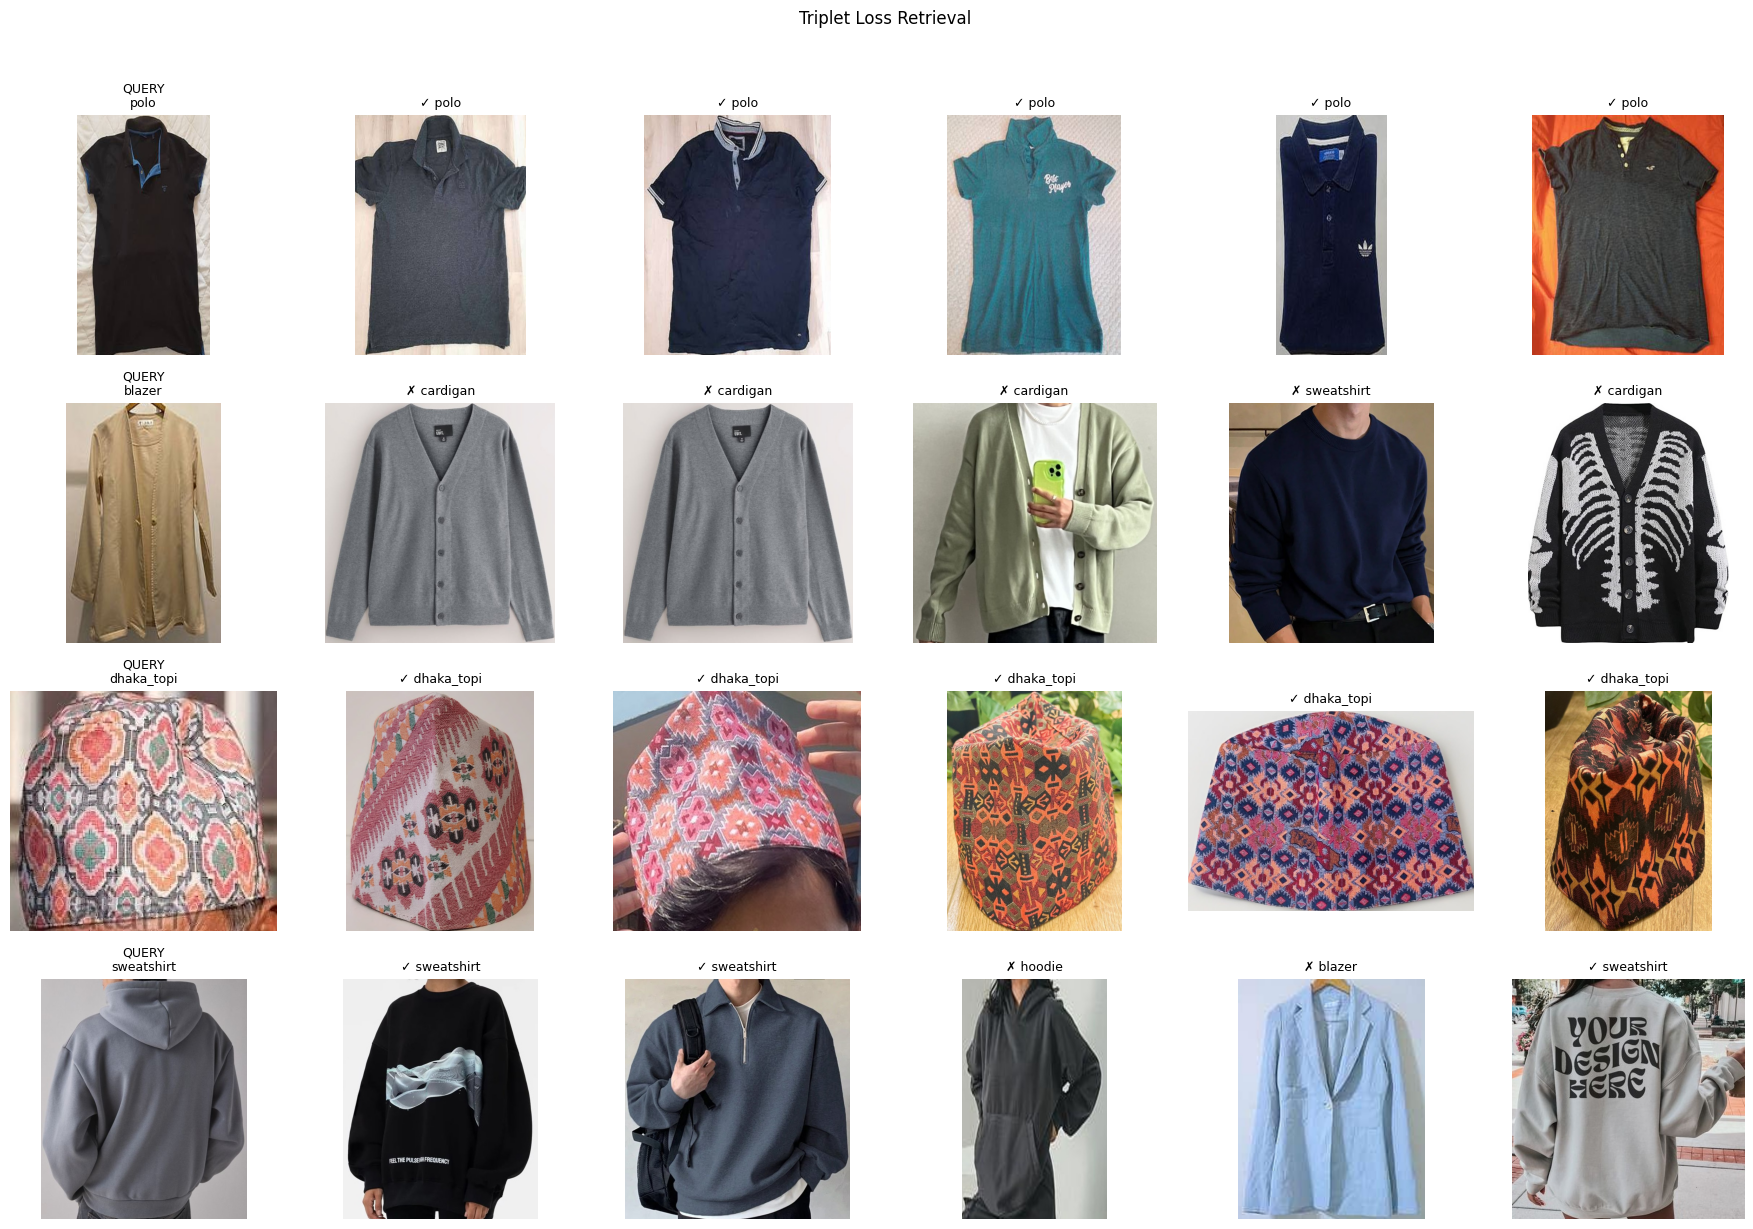

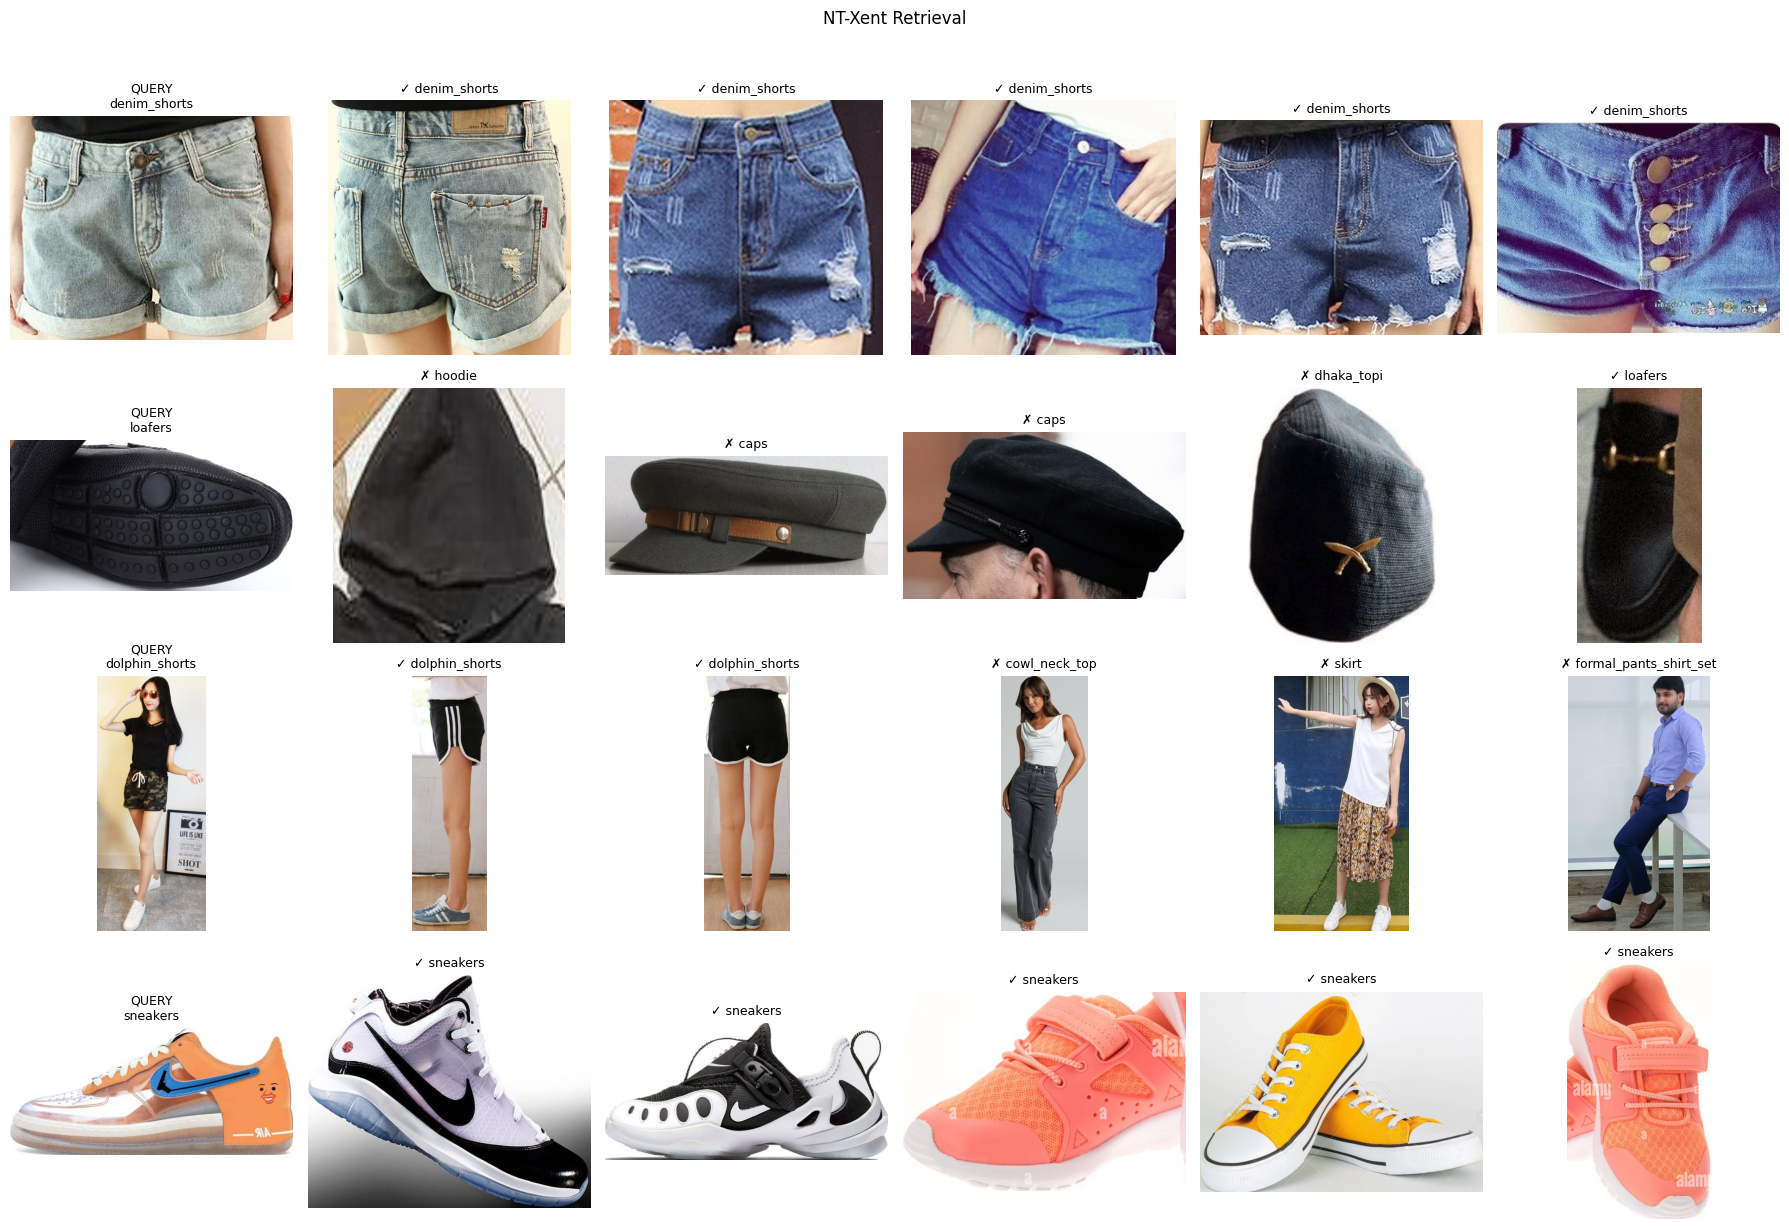

In [19]:
def show_retrieval_example(model, loader_df, embeddings, labels, query_idx, title, ax_row=None):
    sim = embeddings @ embeddings.t()
    sim[query_idx, query_idx] = float("-inf")
    top5 = sim[query_idx].topk(5).indices.tolist()

    if ax_row is None:
        fig, ax_row = plt.subplots(1, 6, figsize=(18, 3))
        fig.suptitle(title)

    query_path = loader_df.iloc[query_idx]["crop_path"]
    ax_row[0].imshow(Image.open(query_path))
    ax_row[0].set_title(f"QUERY\n{loader_df.iloc[query_idx]['class_name']}", fontsize=9)
    ax_row[0].axis("off")

    for i, idx in enumerate(top5):
        path = loader_df.iloc[idx]["crop_path"]
        ax_row[i + 1].imshow(Image.open(path))
        match = "✓" if labels[idx] == labels[query_idx] else "✗"
        ax_row[i + 1].set_title(f"{match} {loader_df.iloc[idx]['class_name']}", fontsize=9)
        ax_row[i + 1].axis("off")


def show_retrieval_batch(model, loader_df, embeddings, labels, title, n_examples=4, seed=None):
    if seed is not None:
        rng = random.Random(seed)
    else:
        rng = random

    query_indices = rng.sample(range(len(loader_df)), n_examples)

    fig, axes = plt.subplots(n_examples, 6, figsize=(18, 3 * n_examples))
    fig.suptitle(title, y=1.02)
    for row, query_idx in enumerate(query_indices):
        show_retrieval_example(model, loader_df, embeddings, labels, query_idx, title, ax_row=axes[row])
    plt.tight_layout()
    plt.show()


test_df_reset = test_df.reset_index(drop=True)

show_retrieval_batch(model_triplet, test_df_reset, emb_trip, labels_trip, "Triplet Loss Retrieval", n_examples=4)
show_retrieval_batch(model_ntxent, test_df_reset, emb_nt, labels_nt, "NT-Xent Retrieval", n_examples=4)